<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_1_Classification_Basics/18_1_3_ROC_AUC_Threshold_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification Part 3
## ROC Curves and Threshold Tuning

Author: Brad Sheese

---

## Introduction
When we evaluate a model, we often get stuck on a single set of numbers. However, changing the decision threshold, the cutoff where we classify an observation as "1" instead of "0", can drastically shift our model's performance. This creates a dilemma: if Model A is better at one threshold but Model B is better at another, which one is truly the superior classifier?

In this notebook, we move beyond single points to evaluate the ROC (Receiver Operating Characteristic) curve and its summary metric, the AUC (Area Under the Curve). These tools allow us to visualize and measure a model's performance across all possible thresholds at once.

Once we have the right model, we will move from theory to practice by:

- Using Youden's J statistic to identify a mathematically "optimal" balance.

- Tuning thresholds based on real-world business costs, where the price of a False Positive rarely equals the price of a False Negative.

### Learning Objectives
By the end of this notebook, you will be able to:
1. Interpret ROC curves and understand the trade-off between TPR and FPR.
2. Use AUC to compare the performance of different models.
3. Understand why precision-recall curves are sometimes better than ROC curves for imbalanced data.
4. Calculate Youden's J to find the "goldilocks" decision boundary.
5. Pick a threshold based on real business costs, not just mathematical optimality.

## Section 1: Setup and Data Loading

As before, we'll train our balanced XGBoost model on the South German Credit data.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import roc_curve, auc, precision_recall_curve, recall_score, precision_score, average_precision_score
from sklearn.metrics import confusion_matrix, classification_report

data = fetch_openml(name='credit-g', version=1, as_frame=True)
df = data.frame

y = (df['class'] == 'bad').astype(int)
X = df.drop(columns=['class'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Ommitted step: Calculate scale_pos_weight for class imbalance
# We do NOT calculate scale_pos_weight here because we are doing to
# tune the decision threshold, instead. You do not do both.

# Update the XGBoost model parameters
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42,
    enable_categorical=True,
    tree_method='hist'
)
model.fit(X_train, y_train)


y_proba = model.predict_proba(X_test)[:, 1]
print("Model ready for evaluation.")


Model ready for evaluation.


## Section 2: The ROC Curve (TPR vs. FPR)

The ROC curve plots two metrics against each other as we slide our threshold from 0 to 1:

1.  True Positive Rate (TPR): Same as recall. "Of all defaults, how many did we catch?"
2.  False Positive Rate (FPR): "Of all good customers, how many did we wrongly flag?"

### What to Look For:
- A perfect model would hug the top-left corner (TPR=1, FPR=0): catch all defaulters, flag zero good customers.
- A random model would be a diagonal line (the chance line): no better than flipping a coin.
- The more "arched" the curve is toward the top-left, the better the model is at separating the two classes.

### What AUC Actually Means

The AUC (Area Under the Curve) is one of the most widely used threshold-independent metrics for model comparison. It represents the probability that the model will rank a randomly chosen positive instance higher than a randomly chosen negative one.

Concrete example: If you randomly pick one defaulter and one good customer from the test set, an AUC of 0.80 means the model will correctly assign a higher default probability to the defaulter 80% of the time. An AUC of 0.50 means the model is no better than a coin flip.

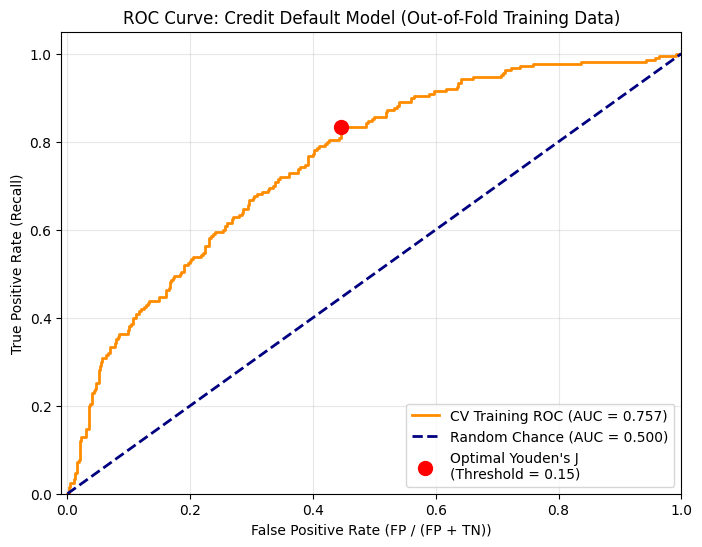

Out-of-Fold Training AUC = 0.757
Optimal Threshold (Youden's J) = 0.151

Interpretation: If you randomly pick one defaulter
and one good customer, the model correctly ranks the
defaulter as higher-risk 75.7% of the time.


In [5]:
oof_train_probs = cross_val_predict(model, X_train, y_train, cv=5, method='predict_proba')[:, 1]

# 1. Calculate the ROC curve points using CROSS-VALIDATED TRAINING DATA
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, oof_train_probs)
roc_auc_train = auc(fpr_train, tpr_train)

# 2. Find Youden's J optimal point on the TRAINING data
j_scores = tpr_train - fpr_train
best_idx = np.argmax(j_scores)
best_tpr = tpr_train[best_idx]
best_fpr = fpr_train[best_idx]
optimal_j_threshold = thresholds_train[best_idx]  # Extract the actual threshold!

# 3. Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2,
         label=f'CV Training ROC (AUC = {roc_auc_train:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Random Chance (AUC = 0.500)')
# Mark the Youden's J optimal point and display the threshold
plt.scatter([best_fpr], [best_tpr], color='red', s=100, zorder=5,
            label=f"Optimal Youden's J\n(Threshold = {optimal_j_threshold:.2f})")

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FP / (FP + TN))')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve: Credit Default Model (Out-of-Fold Training Data)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Out-of-Fold Training AUC = {roc_auc_train:.3f}")
print(f"Optimal Threshold (Youden's J) = {optimal_j_threshold:.3f}")
print(f"\nInterpretation: If you randomly pick one defaulter")
print(f"and one good customer, the model correctly ranks the")
print(f"defaulter as higher-risk {roc_auc_train*100:.1f}% of the time.")

### Reading the Curve

The red dot marks the Youden's J optimal point — the threshold that maximizes TPR while minimizing FPR. Look at where it sits:

- At the far left (low FPR): The model is very conservative. It catches few defaulters but barely flags any good customers.
- At the top (high TPR): The model catches almost all defaulters but also flags many good customers.
- The "knee" of the curve is where you get the most TPR for the least FPR — this is typically close to the Youden's J point.

An AUC of 0.790 means the model is acceptable at distinguishing defaulters from good customers.

## Interpreting AUC Scores

The "Acceptable" label isn't a mathematical law, but rather a widely used industry benchmark for model performance. In the world of credit scoring and binary classification, practitioners often use a scale to translate the abstract AUC number into a grade.

### 1. The Standard Grading Scale
Most data scientists follow a heuristic (rule of thumb) similar to school letter grades to describe AUC:

| AUC Score | Quality / Interpretation |
| :--- | :--- |
| **0.50** | **No Skill:** No better than a coin flip. |
| **0.60 – 0.70** | **Poor:** Better than random, but not very useful for high-stakes decisions. |
| **0.70 – 0.80** | **Acceptable:** The model has a solid grasp of the patterns but still makes mistakes. |
| **0.80 – 0.90** | **Excellent:** Strong predictive power; highly reliable for decision-making. |
| **0.90 – 1.00** | **Outstanding:** Rare in real-world messy data (often suggests "data leakage"). |



### 2. Why 0.790 is "Acceptable"
At 0.790, you are sitting right at the top end of the "Acceptable" range, nearly crossing into "Excellent."

In the context of defaulters vs. good customers, an AUC of 0.790 means that if you randomly presented the model with one person who will default and one who won't, the model will correctly rank the defaulter as "riskier" 79% of the time.

* It’s not perfect: It will still get the ranking wrong about 21% of the time.
* Is it useful? In finance, even a modest improvement over random guessing can save millions of dollars in bad debt, making 0.790 a very respectable and "acceptable" production-ready score.

### 3. Context Matters
The definition of "acceptable" changes based on the cost of an error:
* **Low Stakes (Netflix Recommendations):** An AUC of 0.70 might be "Excellent" because the cost of a bad movie suggestion is tiny.
* **High Stakes (Cancer Detection):** An AUC of 0.80 might be considered "Poor" or "Unacceptable" because a 20% error rate in ranking healthy vs. sick patients is too risky.
* **Finance (Credit Scores):** 0.790 is generally considered a strong, "acceptable" baseline because human behavior is inherently somewhat unpredictable.



## Section 3: ROC vs. Precision-Recall Curves

While ROC curves are standard, they can be over-optimistic on imbalanced data. Here's why:

- The FPR denominator is all actual negatives (good customers). If you have hundreds of good customers, your FPR stays low even if you have dozens of false positives. The ROC curve looks great because the true negatives overwhelm the false positives in the denominator.

The precision-recall (PR) curve is more "honest" for imbalanced data because it ignores true negatives entirely. Precision only asks: "of the people we flagged, how many were actually bad?" If you flag many good customers, precision drops, regardless of how many true negatives you have.

Let's compare.

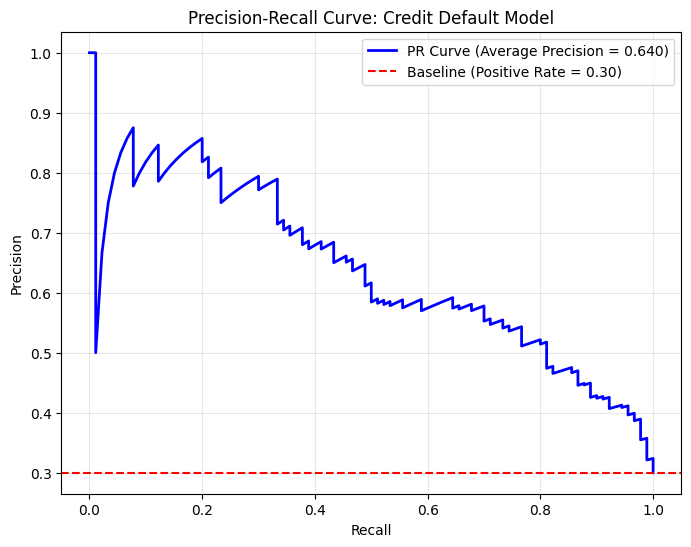

Average Precision = 0.640
Baseline (random guessing precision) = 0.300


In [6]:
from sklearn.metrics import average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_proba)

avg_precision = average_precision_score(y_test, y_proba)
pos_rate = y_test.mean()

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR Curve (Average Precision = {avg_precision:.3f})')
plt.axhline(y=pos_rate, color='red', linestyle='--', label=f'Baseline (Positive Rate = {pos_rate:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Credit Default Model')
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average Precision = {avg_precision:.3f}")
print(f"Baseline (random guessing precision) = {pos_rate:.3f}")

### Reading the PR Curve

The red dashed line shows the baseline precision you'd get from random guessing. For a classifier that simply predicts the positive class with the same probability as the overall positive rate in the dataset:
- If ~30% of applicants are defaulters, a random classifier guessing "defaulter" with 30% probability would achieve ~30% precision.
- Any useful model must stay well above this baseline. The further the PR curve is from this line, the better the model performs on the minority class.

Notice how the PR curve behaves at the extremes:
- At high recall (right side): The model catches most defaulters, but precision drops — many false alarms dilute the positive predictions.
- At high precision (left side): When the model is very selective, precision is high but recall is low. It only flags the most obvious defaulters.

If the PR curve hugs close to the baseline, your model isn't doing much better than random guessing for the minority class, even if the ROC curve looks impressive.

### A Note on Imbalance Severity
Our dataset has a moderate 70/30 class split, so the gap between ROC AUC (0.790) and PR AUC (0.614) is noticeable but not extreme. In truly skewed datasets (e.g., 99/1 fraud detection), the gap becomes dramatic: the ROC AUC can be near 0.99 while the PR AUC reveals the model is nearly useless at identifying positives. The more imbalanced the data, the more important PR curves become.

## Section 4: Finding the "Goldilocks" Threshold (Youden's J)

Now that we've evaluated the *curve*, how do we pick a single *point* (threshold) to use in production?

One common method is Youden's J statistic. It finds the threshold that maximizes the distance between the ROC curve and the random chance line:

$$J = TPR - FPR$$

This finds the threshold that gives you the most "bang for your buck", maximizing detections while minimizing false alarms. It treats both types of error as equally costly, which is a useful starting point but rarely reflects real-world business priorities.

In [7]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve

# Generate out-of-fold probabilities on the training set
oof_train_probs = cross_val_predict(model, X_train, y_train, cv=5, method='predict_proba')[:, 1]

# Calculate ROC points using the OOF training probabilities
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, oof_train_probs)

# Calculate J for all thresholds based on training data
j_scores_train = tpr_train - fpr_train
best_idx = np.argmax(j_scores_train)
best_threshold = thresholds_train[best_idx]

print(f"--- Youden's J Results (Optimized on Training OOF) ---")
print(f"Best Threshold: {best_threshold:.3f}")
print(f"Max J-Score on Train: {j_scores_train[best_idx]:.3f}")

# Now evaluate this threshold's performance on the Test Set
y_test_preds = (y_proba >= best_threshold).astype(int)
test_tpr = recall_score(y_test, y_test_preds)
test_fpr = ((y_test_preds == 1) & (y_test == 0)).sum() / (y_test == 0).sum()

print(f"\n--- Performance on Test Set using optimized threshold ---")
print(f"TPR (Recall): {test_tpr:.3f}")
print(f"FPR:          {test_fpr:.3f}")

# Compare to default 0.5
y_default = (y_proba >= 0.5).astype(int)
default_tpr = recall_score(y_test, y_default)
default_fpr = ((y_default == 1) & (y_test == 0)).sum() / (y_test == 0).sum()
print(f"\n--- For Comparison: Default Threshold (0.5) ---")
print(f"TPR (Recall): {default_tpr:.3f}")
print(f"FPR:          {default_fpr:.3f}")

--- Youden's J Results (Optimized on Training OOF) ---
Best Threshold: 0.151
Max J-Score on Train: 0.388

--- Performance on Test Set using optimized threshold ---
TPR (Recall): 0.867
FPR:          0.443

--- For Comparison: Default Threshold (0.5) ---
TPR (Recall): 0.467
FPR:          0.105


## Section 5: Business Cost Sensitivity

While Youden's J is mathematically optimal, it assumes that a false positive and a false negative have equal cost. In the real world, they rarely do.

Assume:
- A false positive (wrongly denying a loan) costs the bank 500 in lost interest.
- A false negative (wrongly approving a bad loan) costs the bank 5,000 in lost principal.

In this case, we would want to move our threshold to be much more sensitive to catch those defaults, even if it means more false alarms.

--- Threshold Optimization (Training Data Only) ---
Optimal Threshold: 0.04
Estimated Cost per Applicant: $307.14


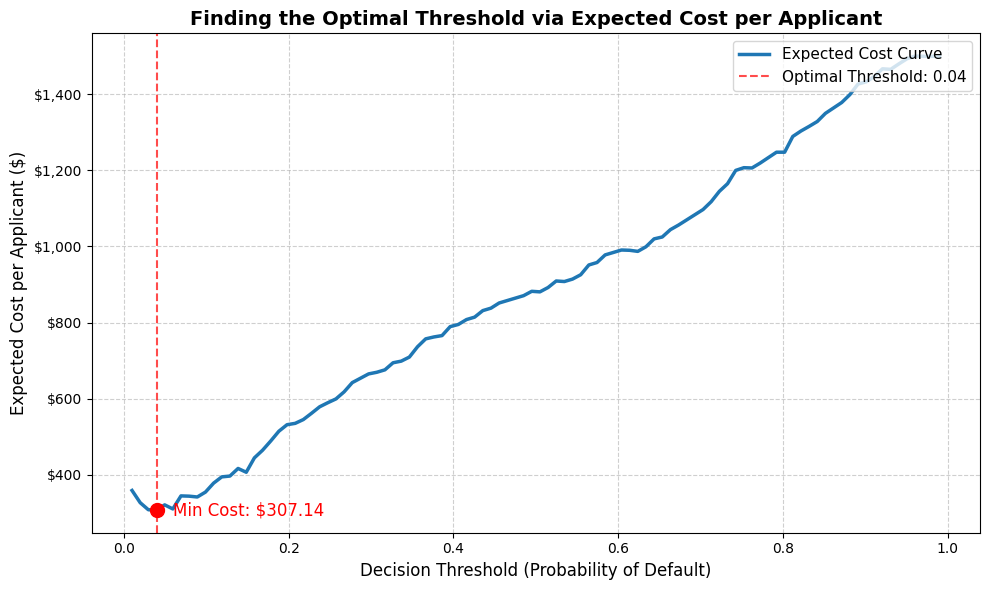


--- Final Test Set Performance ---
Actual Test Cost per Applicant: $285.00

Confusion Matrix:
[[ 49 161]
 [  1  89]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.23      0.38       210
           1       0.36      0.99      0.52        90

    accuracy                           0.46       300
   macro avg       0.67      0.61      0.45       300
weighted avg       0.79      0.46      0.42       300



In [8]:


#=====================================================================
# STEP 1: Find the Optimal Threshold using ONLY Training Data
# =====================================================================

# Generate out-of-fold probabilities on the training set
oof_train_probs = cross_val_predict(model, X_train, y_train, cv=5, method='predict_proba')[:, 1]

def calculate_expected_cost_per_applicant(y_true, y_prob, threshold, fp_cost=500, fn_cost=5000):
    """Calculates the average expected business cost per loan applicant."""
    y_pred = (y_prob >= threshold).astype(int)

    # Calculate total False Positives and False Negatives
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))

    total_cost = (fp * fp_cost) + (fn * fn_cost)

    # Return the expected cost PER APPLICANT
    return total_cost / len(y_true)

# Test thresholds from 0.01 to 0.99
thresholds = np.linspace(0.01, 0.99, 100)
train_costs_per_applicant =[]

for t in thresholds:
    cost = calculate_expected_cost_per_applicant(y_train, oof_train_probs, t)
    train_costs_per_applicant.append(cost)

# Find the threshold that resulted in the lowest expected cost per applicant
optimal_idx = np.argmin(train_costs_per_applicant)
optimal_threshold = thresholds[optimal_idx]
lowest_train_cost = train_costs_per_applicant[optimal_idx]

print("--- Threshold Optimization (Training Data Only) ---")
print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"Estimated Cost per Applicant: ${lowest_train_cost:.2f}")


# =====================================================================
# STEP 1.5: Visualize the Business-Optimal Threshold (Training Data)
# =====================================================================

plt.figure(figsize=(10, 6))

# Plot the cost curve
plt.plot(thresholds, train_costs_per_applicant, color='#1f77b4', linewidth=2.5,
         label='Expected Cost Curve')

# Highlight the optimal threshold with a vertical line and a red dot
plt.axvline(x=optimal_threshold, color='red', linestyle='--', alpha=0.7,
            label=f'Optimal Threshold: {optimal_threshold:.2f}')
plt.scatter([optimal_threshold], [lowest_train_cost], color='red', s=100, zorder=5)

# Add text to show the exact lowest cost
plt.text(optimal_threshold + 0.02, lowest_train_cost,
         f'Min Cost: ${lowest_train_cost:.2f}',
         color='red', fontsize=12, verticalalignment='center')

# Formatting the plot
plt.title('Finding the Optimal Threshold via Expected Cost per Applicant', fontsize=14, fontweight='bold')
plt.xlabel('Decision Threshold (Probability of Default)', fontsize=12)
plt.ylabel('Expected Cost per Applicant ($)', fontsize=12)

# Make the y-axis show dollar signs
ax = plt.gca()
ax.yaxis.set_major_formatter('${x:,.0f}')

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()

plt.show()



# =====================================================================
# STEP 2: Evaluate the Final Model on the Unseen Test Data
# =====================================================================

# Generate probabilities for the test set
test_probs = model.predict_proba(X_test)[:, 1]

# Apply the threshold we learned from the training data!
# (Notice we are NOT looping over the test data to find a new threshold)
final_test_preds = (test_probs >= optimal_threshold).astype(int)

# Calculate final test cost per applicant
final_test_cost_per_applicant = calculate_expected_cost_per_applicant(y_test, test_probs, optimal_threshold)

print(f"\n--- Final Test Set Performance ---")
print(f"Actual Test Cost per Applicant: ${final_test_cost_per_applicant:.2f}")

# Print the final confusion matrix and classification report
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_test_preds))

print("\nClassification Report:")
print(classification_report(y_test, final_test_preds))

### Interpreting the Cost Curve

The cost curve shows the total estimated dollar cost at each threshold. The minimum point is the threshold that saves the bank the most money.

Notice how the cost-optimal threshold differs from both the default 0.5 and Youden's J. This is because the cost curve directly encodes your business priorities: false negatives are 10x more expensive than false positives, so the optimal threshold shifts lower to catch more defaulters, even at the cost of more false alarms.

Youden's J gives you a mathematically sound starting point, but the right threshold depends on your specific cost structure. Always ask: "What does a false positive cost us? What does a false negative cost us?" Then pick the threshold that minimizes total cost.

## Summary

### Threshold Selection Methods

| Method | Threshold | When to Use | Pros | Cons |
|--------|-----------|-------------|------|------|
| **Default (0.5)** | 0.50 | Quick initial evaluation, balanced datasets | Simple, intuitive | Ignores class imbalance and business costs |
| **Youden's J** | 0.39 | Mathematical optimization, equal error costs | Maximizes TPR - FPR, balanced approach | Assumes equal cost of FP and FN errors |
| **Cost-Optimal** | 0.10 | Real-world business decisions | Minimizes actual monetary losses | Requires accurate cost estimates |

### Evaluation Tools

| Tool | Purpose | Best For |
|------|---------|----------|
| **ROC Curve / AUC** | Measure ranking ability across all thresholds | General model comparison |
| **PR Curve / PR AUC** | Measure performance on the positive (minority) class | Imbalanced datasets where true negatives are abundant |

### Key Takeaways

1. **AUC** tells you the model's ranking ability—the probability it correctly ranks a random defaulter above a random good customer. It's threshold-independent, making it ideal for comparing models.
2. **PR curves** are more honest for imbalanced data. They ignore true negatives and focus on how well the model handles the minority class.
3. **Youden's J** finds the mathematically optimal threshold, the point that maximizes TPR while minimizing FPR.
4. **Business costs** should drive the final threshold choice. The mathematically optimal threshold rarely matches the business-optimal one. Always model your real costs.



## Supplemental Materials
- [Stat Quest Video on ROC and AUC](https://www.youtube.com/watch?v=4jRBRDbJemM)